# Tutorial SVM (Support Vector Machine)

Le SVM offrono un'accuratezza molto elevata rispetto ad altri classificatori come gli alberi decisionali. L'utilizzo di una ___kernel function___ consente di gestire spazi di input non lineari.

Vengono utilizzate in una varietà di applicazioni quali il rilevamento dei volti, il rilevamento delle intrusioni, la classificazione di e-mail, articoli di giornale e pagine web, la classificazione di geni e il riconoscimento della scrittura manuale.

Il classificatore separa i punti dati utilizzando un **iperpiano** con il margine più ampio possibile. Ecco perché un classificatore SVM è anche noto come classificatore discriminativo. SVM trova un iperpiano ottimale che aiuta a classificare nuovi punti dati.

La SVM costruisce un iperpiano nello spazio multidimensionale per separare classi diverse. SVM genera un iperpiano ottimale in modo iterativo, che viene utilizzato per ridurre al minimo l'errore. L'idea centrale di SVM è quella di trovare un iperpiano marginale massimo (MMH) che divida al meglio il set di dati in classi.

### Vettori di supporto
I vettori di supporto sono i punti dati più vicini all'iperpiano. Questi punti definiscono meglio la linea di separazione calcolando i margini. Questi punti sono più rilevanti per la costruzione del classificatore.

### Iperpiano
Un iperpiano è un piano decisionale che separa un insieme di oggetti appartenenti a classi diverse.

### Margine
Un margine è lo spazio tra le due linee sui punti di classe più vicini. Viene calcolato come distanza perpendicolare dalla linea ai vettori di supporto o ai punti più vicini. Se il margine è maggiore tra le classi, allora è considerato un buon margine, mentre un margine minore è un cattivo margine.

Sintetizzando, le SVM ricercano l'iperpiano marginale massimo utilizzando due passaggi:

1. Generano iperpiani che separino le classi nel modo migliore. La figura a sinistra mostra tre iperpiani (nero, blu e arancione). In questo caso, il blu e l'arancione hanno un errore di classificazione più elevato, mentre il nero separa correttamente le due classi.

2. Selezionare l'iperpiano corretto con la massima separazione dai punti più vicini, come mostrato nella figura a destra.

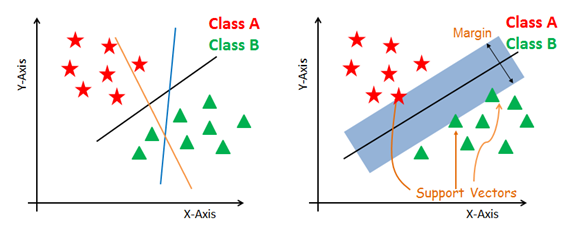

Alcuni problemi non possono essere risolti utilizzando un iperpiano lineare, come mostrato nella figura sottostante (lato sinistro).

In tali situazioni, le SVM utilizzano una _kernel function_ per trasformare lo spazio di input in uno __spazio dimensionale superiore__, come mostrato a destra.

I punti dati sono tracciati sull'asse x e sull'asse z (Z è la somma al quadrato di x e y: z=x^2+y^2). Ora è possibile separare facilmente questi punti utilizzando la separazione lineare.

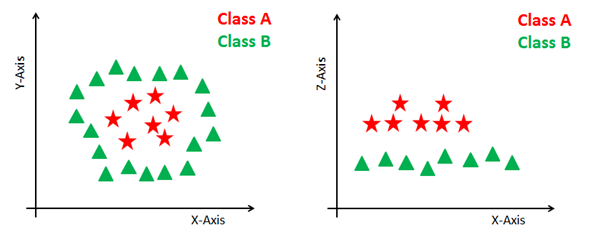

## Kernel functions

- ___Kernel lineare___: Un kernel lineare è un semplice prodotto scalare di due osservazioni qualsiasi. Il prodotto tra due vettori è la somma della moltiplicazione di ciascuna coppia di valori di input: K(x, xi) = sum(x * xi);

- ___Kernel polinomiale___: Un kernel polinomiale è una forma più generalizzata del kernel lineare. Il kernel polinomiale è in grado di distinguere spazi di input curvi o non lineari: K(x,xi) = 1 + sum(x * xi)^d, dove d è uguale al grado del polinomio;

- ___Radial basis function (RBF)___: RBF è una kernel function molto diffusa. L'RBF può mappare uno spazio di input in uno spazio a dimensioni infinite: K(x,xi) = exp(-gamma * sum((x – xi^2)), dove gamma è un parametro che varia da 0 a 1. Un valore più alto di gamma si adatterà perfettamente al set di dati di addestramento, causando un overfitting. Gamma=0,1 è considerato un buon valore predefinito. Il valore di gamma deve essere specificato manualmente nell'algoritmo di apprendimento. Nell'immagine successiva possiamo vedere una visualizzazione in tre dimensioni del comportamento sui dati di una RBF:

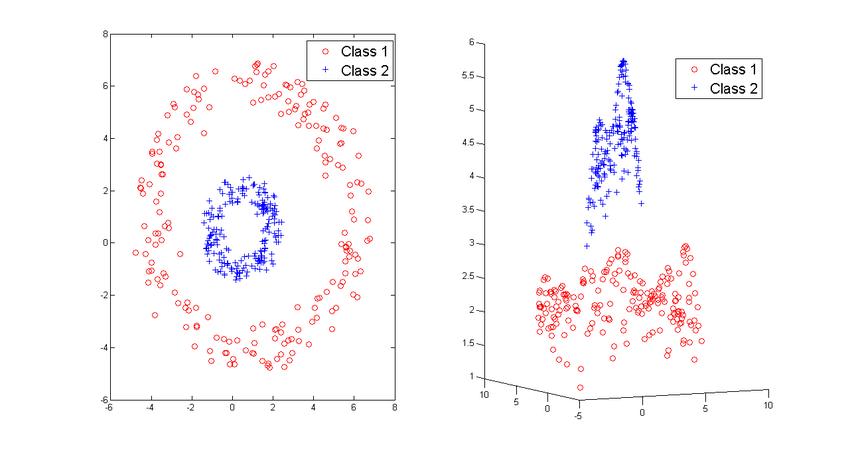

## Implementazione

Utilizzeremo il dataset sul cancro mammario, che è un problema di classificazione multi-classe molto famoso. Questo dataset è calcolato a partire da un'immagine digitalizzata di un aspirato sottile (FNA) di una massa tumorale mammaria. Descrive le caratteristiche dei nuclei cellulari presenti nell'immagine.

Il set di dati comprende 30 caratteristiche (raggio medio, texture media, perimetro medio, area media, levigatezza media, compattezza media, concavità media, punti concavi medi, simmetria media, dimensione frattale media, errore di raggio, errore di texture, errore del perimetro, errore dell'area, errore della levigatezza, errore della compattezza, errore della concavità, errore dei punti concavi, errore della simmetria, errore della dimensione frattale, raggio peggiore, texture peggiore, perimetro peggiore, area peggiore, levigatezza peggiore, compattezza peggiore, concavità peggiore, punti concavi peggiori, simmetria peggiore e dimensione frattale peggiore) e un target (tipo di cancro). Le due classi disponibili per ciascun record sono _malignant_ e _benign_.

Il nostro scopo sarà utilizzare le feature disponibili per predire la classe a cui appartiene la massa tumorale.

### Import delle librerie, caricamento del dataset ed esplorazione

Il primo step sarà quello di importare tutte le funzioni di cui abbiamo bisogno dalle diverse librerie, successivamente caricheremo il dataset (già presente in quelli forniti da SciKit-Learn) e faremo una prima esplorazione dei dati:

In [32]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics

cancer = datasets.load_breast_cancer()

# Trasformiamo feature e target in due DataFrame:
features = pd.DataFrame(cancer.data)
features.columns = cancer.feature_names
target = pd.DataFrame(cancer.target)
target.columns = ['Result']

# print the names of the 30 features
print("Features: ", cancer.feature_names)

print('\n')

# print the label type of cancer('malignant' 'benign')
print("Labels: ", cancer.target_names)

print('\nGeneral information about features')
print(features.info())
print('\nGeneral info about targets')
print(target.info())
print('\nValori possibili per il risultato:')
print(target['Result'].unique())

#features.describe()

Features:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


Labels:  ['malignant' 'benign']

General information about features
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null 

Come visto sopra, caricare un dataset da SciKit-Learn ci fornisce una struttura _simile_ ad un DataFrame di Pandas, dove le colonne sono suddivise in features e target. Possiamo sia trasformare il tutto in un DataFrame per avere accesso ai metodi con i quali abbiamo familiarità, oppure procedere con il dataset non trasformato.

Il passo successivo è quello di dividere i nostri dati in due set diversi: il primo sarà usato per l'addestramento (o _fitting_) del modello, mentre il secondo per valutarne l'accuratezza. Il primo è solitamente più grande del secondo. Un buon rapporto (a seconda di quanti dati abbiamo a disposizione) è 70:30

In [12]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=109) # 70% training and 30% test

In [13]:
X_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
190,14.22,23.12,94.37,609.9,0.10750,0.24130,0.198100,0.06618,0.2384,0.07542,...,15.74,37.18,106.40,762.4,0.15330,0.93270,0.84880,0.17720,0.5166,0.14460
561,11.20,29.37,70.67,386.0,0.07449,0.03558,0.000000,0.00000,0.1060,0.05502,...,11.92,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.058620,0.04835,0.1495,0.05593,...,18.13,25.45,117.20,1009.0,0.13380,0.16790,0.16630,0.09123,0.2394,0.06469
493,12.46,12.83,78.83,477.3,0.07372,0.04043,0.007173,0.01149,0.1613,0.06013,...,13.19,16.36,83.24,534.0,0.09439,0.06477,0.01674,0.02680,0.2280,0.07028
89,14.64,15.24,95.77,651.9,0.11320,0.13390,0.099660,0.07064,0.2116,0.06346,...,16.34,18.24,109.40,803.6,0.12770,0.30890,0.26040,0.13970,0.3151,0.08473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,20.31,27.06,132.90,1288.0,0.10000,0.10880,0.151900,0.09333,0.1814,0.05572,...,24.33,39.16,162.30,1844.0,0.15220,0.29450,0.37880,0.16970,0.3151,0.07999
399,11.80,17.26,75.26,431.9,0.09087,0.06232,0.028530,0.01638,0.1847,0.06019,...,13.45,24.49,86.00,562.0,0.12440,0.17260,0.14490,0.05356,0.2779,0.08121
141,16.11,18.05,105.10,813.0,0.09721,0.11370,0.094470,0.05943,0.1861,0.06248,...,19.92,25.27,129.00,1233.0,0.13140,0.22360,0.28020,0.12160,0.2792,0.08158
245,10.48,19.86,66.72,337.7,0.10700,0.05971,0.048310,0.03070,0.1737,0.06440,...,11.48,29.46,73.68,402.8,0.15150,0.10260,0.11810,0.06736,0.2883,0.07748


In [14]:
y_train

,Result
190,0
561,1
363,1
493,1
89,1
...,...
260,0
399,1
141,0
245,1


### Costruzione del modello

Ora che abbiamo i nostri dati pronti e suddivisi, possiamo passare alla creazione di un modello. Per farlo utilizzeremo la classe SVC di SciKit-Learn.

Istanzieremo una variabile SVC con kernel _lineare_, utilizzeremo i dati di training per il fitting del modello e poi lo utilizzeremo per predire i risultati sui dati di test:

In [35]:
clf = svm.SVC(kernel='linear') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train['Result'])

#Predict the response for test dataset
y_pred = clf.predict(X_test)

print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(y_test, y_pred))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(y_test, y_pred))

Accuracy: 0.9649122807017544
Precision: 0.9811320754716981
Recall: 0.9629629629629629


Ora proviamo a visualizzare i risultati utilizzando una _confusion matrix_, che ci dà un riscontro visivo su dove e quanto sbaglia (e indovina!) il nostro modello:

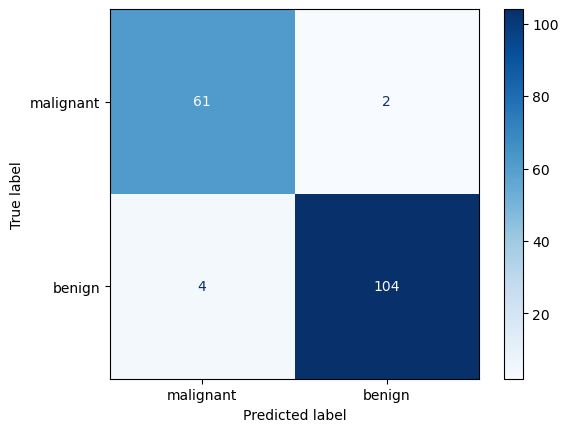

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
disp.plot(cmap=plt.cm.Blues)

In questo caso siamo stati molto fortunati. L'utilizzo di un kernel lineare, utilizzando gli altri parametri disponibili di default, ci ha restituito un modello con un'elevata accuratezza.

In generale è difficile trovarsi di fronte ad una situazione di questo tipo. Spesso c'è bisogno di testare più kernel e parametri per trovare quello ottimale.

Utilizzeremo la funzionalità ___GridSearch___ per testare diversi kernel e iperparametri per trovare la combinazione migliore per la nostra predizione:

Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Accuracy: 0.9498
Accuracy: 0.9707602339181286
Precision: 0.9904761904761905
Recall: 0.9629629629629629


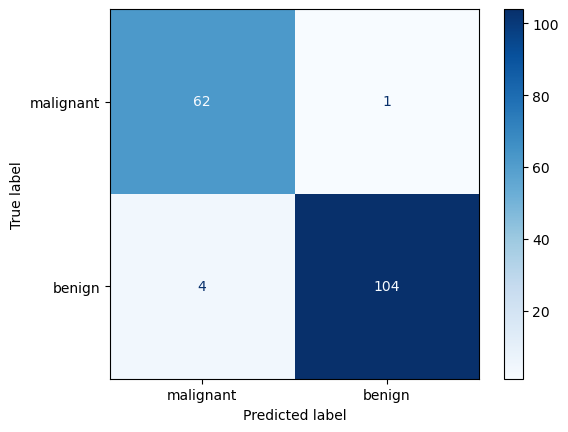

In [39]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for SVC
# C: regularization parameter
# gamma: kernel coefficient for 'rbf'
# kernel: type of SVM kernel
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

# Create SVC model
svc = svm.SVC()

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',   # Metric to optimize
    cv=5,                 # 5-fold cross-validation
    verbose=0,            # Don't show progress
    n_jobs=-1             # Use all CPU cores
)

# Fit the model with grid search
grid_search.fit(X_train, y_train['Result'])

# Display best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy: {:.4f}".format(grid_search.best_score_))

# Evaluate on test set
y_pred = grid_search.predict(X_test)

print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(y_test, y_pred))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
disp.plot(cmap=plt.cm.Blues)